## 3DoF Entry MSL SCP

Imports

In [ ]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Trajopt imports
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.Trajopt as prob
import trajopt.core.modules.utils.config_loader as cfg

create problem and run SCP

In [2]:
# create problem instance
nominal_config  = cfg.load_configs("msl_entry_3dof")
trajopt_obj = prob.Problem(nominal_config)

# run SCP
trajopt_obj = scp.run_scp(trajopt_obj)

scales: 
d: 3396190.0000, t: 956.3609, m: 2900.0000, v: 3551.1593, a: 3.7132, f: 10768.2800, ang: 57.2958, angv: 0.0599, none: 1.0000
Initial guess time: 0.18910354200488655 seconds
Cost initial: 0.30221825614295783
total number of parameters: 5941
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: msl: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------

/opt/anaconda3/envs/TrajGen/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    00513.6   |   0002.5  |   0466.0   |   -3.3    |      -12.0      |    -02.2    |     -12.0   |    optimal    |   205.85   |  1043.6
     02     |    00004.1   |   0002.2  |   0000.6   |   -3.5    |      -12.0      |    -02.2    |     -12.0   |    optimal    |   209.68   |  1022.2
     03     |    00003.5   |   0002.4  |   0000.6   |   -3.6    |      -12.0      |    -02.2    |     -12.0   |    optimal    |   212.35   |  1000.2
     04     |    00003.5   |   0002.3  |   0000.6   |   -3.7    |      -12.0      |    -02.2    |     -12.0   |    optimal    |   214.77   |  967.8
     05     |    00003.5   |   0002.0  |   0000.5   |   -3.4    |      -12.0      |    -02.2    |     -12.0   |    optimal    |   217.96   |  909.2
     06     |    00004.0   |   0002.3  |   0000.6   |   -3.1    |      -12.0      |    -02.3    |     -12.0   |    optimal    |   223.18   |  804.8
     07     |    00003.8   |   0002.3  |   0000.6   |   -2.9    |      -12.0      |    -02.4    |     -12.0  

make plots

final time: 352.0822791481127


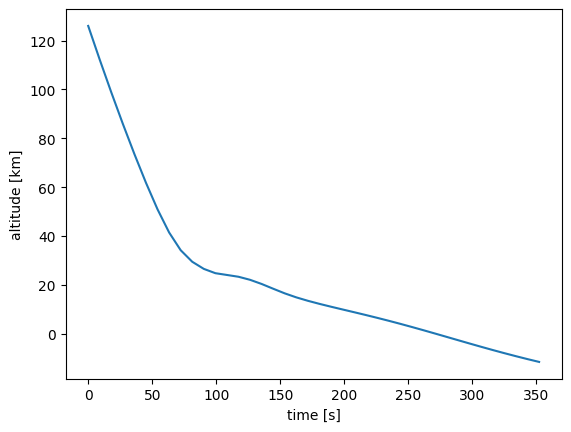

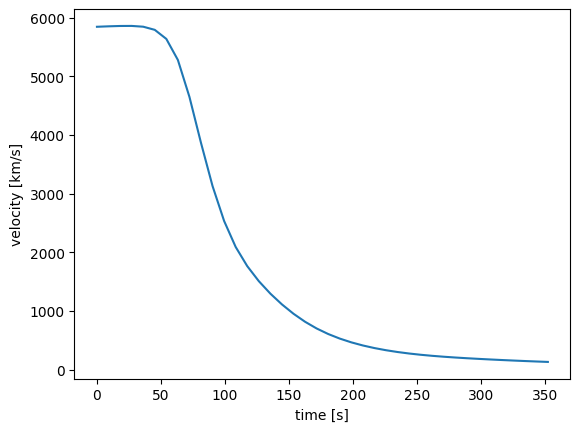

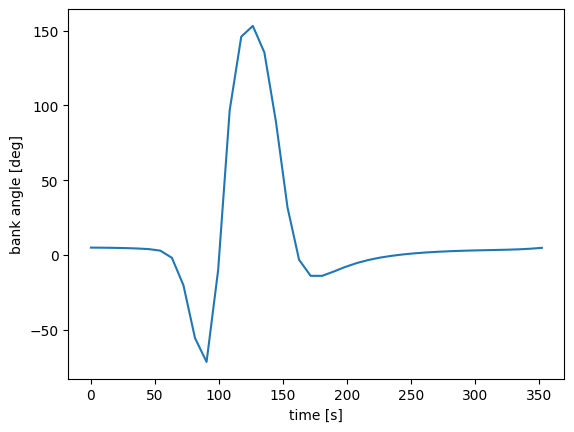

In [3]:
# --- 3D Interactivity (run %matplotlib widget in Jupyter) ---
#%matplotlib widget # ← run this once per notebook session

mission = trajopt_obj.mission
model   = trajopt_obj.model
method  = trajopt_obj.method

# --- Retrieve trajectory and parameters ---

t_init = method.t_init
z_init = method.z_init
nu_init = method.nu_init
x_init  = z_init[:, 0]
y_init  = z_init[:, 1]
z_init  = z_init[:, 2]

t_opt  = trajopt_obj.solution["t_opt"]
z_opt  = trajopt_obj.solution["z_opt"]
nu_opt  = trajopt_obj.solution["nu_opt"]

plt.plot(t_opt * method.nondim['nt'], (z_opt[:, 0] * method.nondim['nd'] - mission.planet['r']) / 1e3)
plt.ylabel('altitude [km]')
plt.xlabel('time [s]')

plt.figure()
plt.plot(t_opt*method.nondim['nt'], (z_opt[:, 3] * method.nondim['nv']))
plt.ylabel('velocity [km/s]')
plt.xlabel('time [s]')

plt.figure()
plt.plot(t_opt*method.nondim['nt'], np.rad2deg(nu_opt[:, 0]))
plt.ylabel('bank angle [deg]')
plt.xlabel('time [s]')

print(f"final time: {t_opt[-1] * method.nondim['nt']}")